# Lab 15 楊婷婷 112078502

* What you should do:  
    - Run the code and comprehense it
    - Write your discovery in this notebook (exempli gratia how many times your birds fly to get more than 10 rewards)

* Evaluation metrics:
    - Report of this lab (50%)
    - The bird is able to fly through at least 1 pipe (50%)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import moviepy.editor as mpy
import skimage.transform
from IPython.display import Image, display

import tensorflow as tf
import tensorflow_probability as tfp
import tensorflow.keras.losses as kls

# for pygame
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"  # this line make pop-out window not appear
from ple.games.flappybird import FlappyBird
from ple import PLE

gpus = tf.config.list_physical_devices("GPU") 
if gpus:
    try:
        # Restrict TensorFlow to only use the fourth GPU
        tf.config.set_visible_devices(gpus[0], 'GPU')

        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

couldn't import doomish
Couldn't import doom
1 Physical GPUs, 1 Logical GPUs


I0000 00:00:1765267920.494610 3631138 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10245 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
game = FlappyBird()
env = PLE(game, fps=30, display_screen=False)  # environment interface to game
env.reset_game()

test_game = FlappyBird()
test_env = PLE(test_game, fps=30, display_screen=False)
test_env.reset_game()


path = './movie_f' 
if not os.path.exists(path):
    os.makedirs(path)

hparas = {
    'image_size': 84,
    'num_stack': 4,
    'action_dim': len(env.getActionSet()),
    'hidden_size': 256,
    'lr': 0.0001,
    'gamma': 0.99,
    'lambda': 0.95,
    'clip_val': 0.2,
    'ppo_epochs': 8,
    'test_epochs': 1,
    'num_steps': 512,
    'mini_batch_size': 64,
    'target_reward': 200,
    'max_episode': 30000,
}

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known inc

# Game frame setting

In [ ]:
# Please do not modify this method
# make_anim: build video using frames
def make_anim(images, fps=60, true_image=False):
    duration = len(images) / fps

    def make_frame(t):
        try:
            x = images[int(len(images) / duration * t)]
        except:
            x = images[-1]

        if true_image:
            return x.astype(np.uint8)
        else:
            return ((x + 1) / 2 * 255).astype(np.uint8)

    clip = mpy.VideoClip(make_frame, duration=duration)
    clip.fps = fps
    
    return clip

# make the frame fit into Atari PPO papers
def preprocess_screen(screen):
    screen = skimage.transform.rotate(screen, -90, resize=True)
    screen = screen[:400, :]
    screen = skimage.transform.resize(screen, [hparas['image_size'], hparas['image_size'], 1])
    return screen.astype(np.float32)
# get the last 4 frames
def frames_to_state(input_frames):
    if(len(input_frames) == 1):
        state = np.concatenate(input_frames*4, axis=-1)
    elif(len(input_frames) == 2):
        state = np.concatenate(input_frames[0:1]*2 + input_frames[1:]*2, axis=-1)
    elif(len(input_frames) == 3):
        state = np.concatenate(input_frames + input_frames[2:], axis=-1)
    else:
        state = np.concatenate(input_frames[-4:], axis=-1)

    return state

# Model

## Network:
* structure: two heads shared the same CNN layers   
-> Actor head, Critic head
-> Used to compute log-probabilities and policy gradients   

1. Actor head(action distribution): Outputs probability distribution of actions (a vector)   
->How likely each action is  
-> Goal: to learm which action to take(i.e. improve the policy) . 

2. Critic head(value estimate) : output state-value estimate V(s)    (a scalar)   
-> predict how good the current state is  
-> Used for advantage estimation (GAE)    
-> Goal: to learn how good a state is (i.e. improve the value function)

forwad pass of actor_critic will output probability distribution of actions, and state-value estimate V(s)

## Agent:

* Loss function:
    - Actor Loss (policy loss): How much better is the new policy than the old one   
    clip: limit how much the policy can change per update (to update more stable)   
    - Critic Loss (value loss): How wrong is the value function ? $V(s_t)$
    -> reward(target values using GAE) - value

In [ ]:
class ActorCriticNetwork(tf.keras.Model):
    def __init__(self, hparas):
        super().__init__()

        self.feature_extractor = tf.keras.Sequential([
          # Convolutional Layers
          tf.keras.layers.Conv2D(filters=32, kernel_size=8, strides=4),
          tf.keras.layers.ReLU(),
          tf.keras.layers.Conv2D(filters=64, kernel_size=4, strides=2),
          tf.keras.layers.ReLU(),
          tf.keras.layers.Conv2D(filters=64, kernel_size=3, strides=1),
          tf.keras.layers.ReLU(),
          # Embedding Layers
          tf.keras.layers.Flatten(),
          tf.keras.layers.Dense(hparas['hidden_size']),
          tf.keras.layers.ReLU(),
        ])

        # Actor Network
        self.actor = tf.keras.layers.Dense(hparas['action_dim'], activation='softmax')
        # Critic Network
        self.critic = tf.keras.layers.Dense(1, activation = None)
    # forward pass:
    def call(self, input):
        x = self.feature_extractor(input)
        action_logits = self.actor(x)
        value = self.critic(x)
        return action_logits, value # probability for each action / V(s)

In [ ]:
class Agent():
    def __init__(self, hparas):
        self.gamma = hparas['gamma']
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=hparas['lr'])
        self.actor_critic = ActorCriticNetwork(hparas)
        self.clip_pram = hparas['clip_val']
    
    # randomly sample minibatches for PPO training 
    def ppo_iter(self, mini_batch_size, states, actions, log_probs, returns, advantage):
        batch_size = states.shape[0]
        for _ in range(batch_size // mini_batch_size):
            rand_ids = tf.convert_to_tensor(np.random.randint(0, batch_size, mini_batch_size), dtype=tf.int32)
            yield tf.gather(states, rand_ids), tf.gather(actions, rand_ids), tf.gather(log_probs, rand_ids), \
             tf.gather(returns, rand_ids), tf.gather(advantage, rand_ids)
    # performing gradient updates
    def ppo_update(self, ppo_epochs, mini_batch_size, states, actions, log_probs, discount_rewards, advantages):       
        total_actor_loss = 0
        total_critic_loss = 0
        for _ in range(ppo_epochs):
            for state, action, old_log_probs, reward, advantage in self.ppo_iter(mini_batch_size, states, actions, log_probs, discount_rewards, advantages):
                reward = tf.expand_dims(reward, axis=-1)

                with tf.GradientTape() as tape:
                    prob, value = self.actor_critic(state, training=True)
                    dist = tfp.distributions.Categorical(probs=prob, dtype=tf.float32)
                    entropy = tf.math.reduce_mean(dist.entropy())
                    new_log_probs = dist.log_prob(action) # new log-probs of sampled actions

                    # PPO ratio = new probs / old probs 
                    ratio = tf.math.exp(new_log_probs - old_log_probs)
                    surr1 = ratio * advantage # how better the an actoin was v.s what the critic expected advantage (A_t) = return_t(actual return from taking action a_t) -V(s_t)predicted value of state s 
                    surr2 = tf.clip_by_value(ratio, 1.0 - self.clip_pram, 1.0 + self.clip_pram) * advantage

                    # loss update
                    actor_loss = tf.math.negative(tf.math.reduce_mean(tf.math.minimum(surr1, surr2))) - 0.1 * entropy
                    critic_loss = 0.5 * tf.math.reduce_mean(kls.MeanSquaredError()(reward, value))

                    total_loss = actor_loss + critic_loss
            
                # single optimizer
                grads = tape.gradient(total_loss, self.actor_critic.trainable_variables)
                self.optimizer.apply_gradients(zip(grads, self.actor_critic.trainable_variables))
      
                total_actor_loss += actor_loss
                total_critic_loss += critic_loss
        return total_actor_loss, total_critic_loss

## GAE
when we get advantages : general is how better the an actoin was v.s what the critic expected     
(A_t) = return_t(actual return from taking action a_t) -V(s_t)predicted value of state s     

GAE reduces variance and stabilizes PPO  
-> GAE = return_t - V(s_t)  
-> TD error = delta = r_t + γ V(s_{t+1}) - V(s_t)  
-> smoothed advantage   A_t = GAE_t =  δ + γλ GAE_{t+1}    
-> return_t = A_t + V(s_t) 

In [16]:
# https://arxiv.org/pdf/1506.02438.pdf
# Equation 16
def compute_gae(rewards, masks, values, gamma, LAMBDA):
    gae = 0
    returns = []
    for i in reversed(range(len(rewards))):
        delta = rewards[i] + gamma * values[i + 1] * masks[i] - values[i]
        gae = delta + gamma * LAMBDA * masks[i] * gae
        returns.append(gae + values[i])

    returns.reverse()
    return returns

# test env

In [22]:
def test_reward(test_env, agent):
    total_reward = 0
    # Reset the environment
    test_env.reset_game()
    input_frames = [preprocess_screen(test_env.getScreenGrayscale())]

    while not test_env.game_over():

        state = frames_to_state(input_frames)
        state = tf.expand_dims(state, axis=0)
        prob, value = agent.actor_critic(state)

        action = np.argmax(prob[0].numpy())
        reward = test_env.act(test_env.getActionSet()[action])
        total_reward += reward

        input_frames.append(preprocess_screen(test_env.getScreenGrayscale()))

    return total_reward

# Training

-> Rolling out "num_stets" of interatction with the env.  
-> store: states, actions, rewards, log_probs, masks(1 is alive), values  
-> compute GAE advantages  
-> perform PPO updates (8 epochs * mini batches)  
-> test and save model  
-> stop early check  

In [23]:
agent = Agent(hparas)
max_episode = hparas['max_episode']
test_per_n_episode = 10
force_save_per_n_episode = 1000
early_stop_reward = 10

start_s = 0
best_reward = -5.0

checkpoint = tf.train.Checkpoint(
    actor_critic = agent.actor_critic,
    optimizer = agent.optimizer,
)

# Load from old checkpoint
# checkpoint.restore('ckpt_dir/ckpt-?')

In [24]:
ep_reward = []
total_avgr = []
early_stop = False
avg_rewards_list = []

env.reset_game()

for s in range(0, max_episode):
    if early_stop == True:
        break

    rewards = []
    states = []
    actions = []
    log_probs = []
    masks = []
    values = []

    display_frames = [env.getScreenRGB()]
    input_frames = [preprocess_screen(env.getScreenGrayscale())]

    for step in range(hparas['num_steps']):

        state = frames_to_state(input_frames)
        state = tf.expand_dims(state, axis=0)
        prob, value = agent.actor_critic(state)

        dist = tfp.distributions.Categorical(probs=prob[0], dtype=tf.float32)
        action = dist.sample(1)
        log_prob = dist.log_prob(action)

        reward = env.act(env.getActionSet()[int(action.numpy())])

        done = env.game_over()

        states.append(state)
        actions.append(action)
        values.append(value[0])
        log_probs.append(log_prob)
        rewards.append(tf.convert_to_tensor(reward, dtype=tf.float32))
        masks.append(tf.convert_to_tensor(1-int(done), dtype=tf.float32))

        display_frames.append(env.getScreenRGB())
        input_frames.append(preprocess_screen(env.getScreenGrayscale()))

        if done:
            env.reset_game()
            input_frames = [preprocess_screen(env.getScreenGrayscale())]
  
    _, next_value = agent.actor_critic(state)
    values.append(next_value[0])

    returns = compute_gae(rewards, masks, values, hparas['gamma'], hparas['lambda'])

    returns = tf.concat(returns, axis=0)
    log_probs = tf.concat(log_probs, axis=0)
    values = tf.concat(values, axis=0)
    states = tf.concat(states, axis=0)
    actions = tf.concat(actions, axis=0)
    advantage = returns - values[:-1]

    a_loss, c_loss = agent.ppo_update(hparas['ppo_epochs'], hparas['mini_batch_size'], states, actions, log_probs, returns, advantage)
    print('[Episode %d]  Actor loss: %.5f, Critic loss: %.5f' % (s, a_loss, c_loss))

    if s % test_per_n_episode == 0:
        # test agent hparas['test_epochs'] times to get the average reward
        avg_reward = np.mean([test_reward(test_env, agent) for _ in range(hparas['test_epochs'])])
        print("Test average reward is %.1f, Current best average reward is %.1f\n" % (avg_reward, best_reward))
        avg_rewards_list.append(avg_reward)

        if avg_reward > best_reward:
            best_reward = avg_reward
            agent.actor_critic.save('./save/Actor/model_actor_{}_{}.h5'.format(s, avg_reward), save_format="tf")
            checkpoint.save(file_prefix = './save/checkpoints/ckpt')

    if s % force_save_per_n_episode == 0:
        agent.actor_critic.save('./save/Actor/model_actor_{}_{}.h5'.format(s, avg_reward), save_format="tf")
        checkpoint.save(file_prefix = './save/checkpoints/ckpt')
        clip = make_anim(display_frames, fps=60, true_image=True).rotate(-90)
        clip.write_videofile("movie_f/{}_demo-{}.webm".format('Lab15', s), fps=60)
        display(clip.ipython_display(fps=60, autoplay=1, loop=1, maxduration=120))

    if best_reward >= early_stop_reward:
        early_stop = True

[Episode 0]  Actor loss: 93.17406, Critic loss: 61.99674


Test average reward is -5.0, Current best average reward is -5.0

Moviepy - Building video movie_f/Lab15_demo-0.webm.
Moviepy - Writing video movie_f/Lab15_demo-0.webm



Moviepy - Done !
Moviepy - video ready movie_f/Lab15_demo-0.webm
Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


[Episode 1]  Actor loss: 52.90323, Critic loss: 32.95708
[Episode 2]  Actor loss: 40.47044, Critic loss: 23.32496
[Episode 3]  Actor loss: 14.26904, Critic loss: 13.17264
[Episode 4]  Actor loss: 4.68026, Critic loss: 7.13656
[Episode 5]  Actor loss: 9.66718, Critic loss: 5.32104
[Episode 6]  Actor loss: 2.45600, Critic loss: 4.12674
[Episode 7]  Actor loss: -5.60919, Critic loss: 3.69353
[Episode 8]  Actor loss: -5.25925, Critic loss: 2.47469
[Episode 9]  Actor loss: -6.65101, Critic loss: 2.88364
[Episode 10]  Actor loss: -12.33560, Critic loss: 2.24057
Test average reward is -5.0, Current best average reward is -5.0

[Episode 11]  Actor loss: -8.79414, Critic loss: 1.81128
[Episode 12]  Actor loss: -9.78874, Critic loss: 2.37099
[Episode 13]  Actor loss: -3.33760, Critic loss: 1.76613
[Episode 14]  Actor loss: -8.98667, Critic loss: 2.45399
[Episode 15]  Actor loss: -10.34642, Critic loss: 1.27981
[Episode 16]  Actor loss: -3.63970, Critic loss: 2.08648
[Episode 17]  Actor loss: -2.

...

[Episode 1001]  Actor loss: -9.49100, Critic loss: 1.83227
[Episode 1002]  Actor loss: -17.47696, Critic loss: 1.28026
[Episode 1003]  Actor loss: -20.21785, Critic loss: 1.41847
[Episode 1004]  Actor loss: -5.48541, Critic loss: 1.13806
[Episode 1005]  Actor loss: -13.59062, Critic loss: 1.17803
[Episode 1006]  Actor loss: -6.23618, Critic loss: 1.56590
[Episode 1007]  Actor loss: -10.52912, Critic loss: 2.06252
[Episode 1008]  Actor loss: 1.91511, Critic loss: 2.06692
[Episode 1009]  Actor loss: -6.07951, Critic loss: 1.22535
[Episode 1010]  Actor loss: -6.11281, Critic loss: 1.69731
Test average reward is -5.0, Current best average reward is -2.0

[Episode 1011]  Actor loss: -2.82955, Critic loss: 3.66802
[Episode 1012]  Actor loss: 5.95618, Critic loss: 3.12729
[Episode 1013]  Actor loss: 3.51159, Critic loss: 2.33128
[Episode 1014]  Actor loss: -1.86121, Critic loss: 3.67820
[Episode 1015]  Actor loss: -0.39489, Critic loss: 2.61523
[Episode 1016]  Actor loss: -4.51172, Critic los

Test average reward is -1.0, Current best average reward is -2.0

[Episode 1061]  Actor loss: -13.78681, Critic loss: 1.08742
[Episode 1062]  Actor loss: -19.10224, Critic loss: 2.15066
[Episode 1063]  Actor loss: -10.94363, Critic loss: 5.62289
[Episode 1064]  Actor loss: -10.44688, Critic loss: 2.67845
[Episode 1065]  Actor loss: -7.82426, Critic loss: 2.00112
[Episode 1066]  Actor loss: -3.84578, Critic loss: 2.54571
[Episode 1067]  Actor loss: -15.90446, Critic loss: 3.83230
[Episode 1068]  Actor loss: -15.67668, Critic loss: 4.14075
[Episode 1069]  Actor loss: -2.39295, Critic loss: 1.43957
[Episode 1070]  Actor loss: 0.26250, Critic loss: 2.42743
Test average reward is -5.0, Current best average reward is -1.0

[Episode 1071]  Actor loss: 1.73456, Critic loss: 1.26777
[Episode 1072]  Actor loss: -18.64422, Critic loss: 1.86002
[Episode 1073]  Actor loss: -5.25044, Critic loss: 2.06829
[Episode 1074]  Actor loss: -12.89375, Critic loss: 1.80540
[Episode 1075]  Actor loss: -2.80836

Test average reward is 3.0, Current best average reward is -1.0

[Episode 1321]  Actor loss: -20.36133, Critic loss: 3.42243
[Episode 1322]  Actor loss: -16.87449, Critic loss: 2.23252
[Episode 1323]  Actor loss: -8.62965, Critic loss: 5.07015
[Episode 1324]  Actor loss: -4.96607, Critic loss: 3.37327
[Episode 1325]  Actor loss: 19.52875, Critic loss: 2.85439
[Episode 1326]  Actor loss: 2.98180, Critic loss: 1.30115
[Episode 1327]  Actor loss: -8.82079, Critic loss: 2.97670
[Episode 1328]  Actor loss: 2.55127, Critic loss: 1.20214
[Episode 1329]  Actor loss: -1.55979, Critic loss: 1.06153
[Episode 1330]  Actor loss: -14.57164, Critic loss: 1.43899
Test average reward is -2.0, Current best average reward is 3.0

[Episode 1331]  Actor loss: -10.09115, Critic loss: 0.96110
[Episode 1332]  Actor loss: -6.14657, Critic loss: 2.75881
[Episode 1333]  Actor loss: -10.37136, Critic loss: 2.59332
[Episode 1334]  Actor loss: -18.30837, Critic loss: 3.12651
[Episode 1335]  Actor loss: 7.28918, Cri

Test average reward is 4.0, Current best average reward is 3.0

[Episode 1571]  Actor loss: -4.73863, Critic loss: 3.63863
[Episode 1572]  Actor loss: -7.68540, Critic loss: 4.09619
[Episode 1573]  Actor loss: -18.33759, Critic loss: 3.05851
[Episode 1574]  Actor loss: -16.22686, Critic loss: 2.66435
[Episode 1575]  Actor loss: -26.30016, Critic loss: 3.54728
[Episode 1576]  Actor loss: 5.46407, Critic loss: 6.69851
[Episode 1577]  Actor loss: -3.07555, Critic loss: 6.02317
[Episode 1578]  Actor loss: -16.91235, Critic loss: 3.62493
[Episode 1579]  Actor loss: -1.93100, Critic loss: 4.96901
[Episode 1580]  Actor loss: 21.65631, Critic loss: 6.87965
Test average reward is -4.0, Current best average reward is 4.0

[Episode 1581]  Actor loss: -14.31858, Critic loss: 8.98231
[Episode 1582]  Actor loss: -7.37306, Critic loss: 6.18582
[Episode 1583]  Actor loss: -11.74185, Critic loss: 4.57091
[Episode 1584]  Actor loss: 0.28300, Critic loss: 3.33472
[Episode 1585]  Actor loss: 4.58078, Crit

Test average reward is 12.0, Current best average reward is 4.0



# Report

## 1. Report and discovery
* Run the code and comprehense it -> please see above markdown section of "Model", for comprehensive explanation   
* Discovery: use below chart to explain,  
    - at early learning (before 1000 episode), takes time to extract useful visual features at beginning.
    - at around 1200 episode, it has breakthrough (avg_reward starts to get positive), policy learned not to crash immediately
    - Even thought we terminate early(using TA code's early stop criteria), we see it is still very unstable but it has very high possibility that we can pass at least one pipe at later episodes 
    - Despite the unstable, we can see the overall curve, the policy kept improving !

## 2. result of running (The bird is able to fly through at least 1 pipe)
see the last log at episode 1830 : Test average reward is 12.0, Current best average reward is 4.0, which can likely fly through at least 1 pipe  

In [30]:
print(f'Best reward: {best_reward}')

Best reward: 12.0


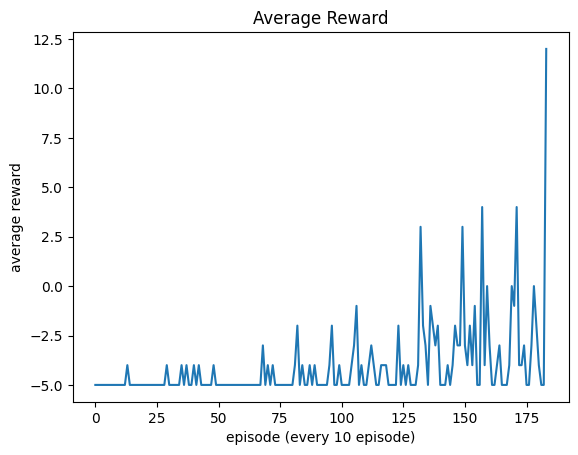

In [29]:
import matplotlib.pyplot as plt

plt.plot(range(len(avg_rewards_list)), avg_rewards_list)
plt.title('Average Reward')
plt.xlabel('episode (every 10 episode)')
plt.ylabel('average reward')
plt.show()